# Wykrywanie choroby serca - klasyfikacja

**Sprawozdanie z projektu zaliczeniowego - Uczenie maszynowe w chmurze**

Autorzy: Jakub Rosa i Dawid Stasiak  
Zbiór danych: [UCI Heart Disease Dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data)

---

## 1. Wprowadzenie

Celem projektu jest zbudowanie i porównanie modeli klasyfikacyjnych przewidujących, czy pacjent cierpi na chorobę serca, na podstawie danych medycznych.

Problem sprowadzono do **klasyfikacji binarnej**: pacjent zdrowy (0) lub chory (1).

Porównano cztery algorytmy uczenia maszynowego:
- **MLPClassifier** (sieć neuronowa scikit-learn) + sieć w **TensorFlow/Keras** uruchomioną na GPU,
- **Support Vector Classifier (SVC)**,
- **K-Nearest Neighbors (KNN)**,
- **Random Forest Classifier (RFC)**.

### Kontekst medyczny - wybór metryki

W diagnostyce medycznej nie wszystkie błędy są równie kosztowne. Zaklasyfikowanie chorego pacjenta jako zdrowego oznacza brak leczenia i jest znacznie groźniejsze niż fałszywy alarm. Dlatego jako **główną metrykę optymalizacji przyjęto recall (czułość)** dla klasy "chory", a nie accuracy (dokładność) - accuracy może pozostać wysokie nawet gdy model przeocza chorych, o ile zdrowych pacjentów jest więcej.

In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from tensorflow import keras
from typing import List
from sklearn.neighbors import KNeighborsClassifier as KNC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.inspection import permutation_importance

# Downloading dataset

In [2]:
# CONSTANTS
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5
SCORING = 'recall'

In [3]:
results_a = {}
results_r = {}
results_p = {}

## 2. Opis zbioru danych

Zbiór zawiera **303 rekordy** pacjentów opisane 13 cechami medycznymi oraz zmienną docelową. Po usunięciu wierszy z brakującymi wartościami pozostało **297 rekordów** (szczegóły w rozdziale 3).

### Cechy w zbiorze

| Cecha | Opis | Typ |
|-------|------|-----|
| **age** | Wiek pacjenta (lata) | liczbowa |
| **sex** | Płeć (1 = mężczyzna, 0 = kobieta) | binarna |
| **cp** | Typ bólu w klatce piersiowej:<br>`1` - typowa dławica piersiowa<br>`2` - atypowa dławica piersiowa<br>`3` - ból niedławicowy<br>`4` - bezobjawowy | kategoryczna |
| **trestbps** | Spoczynkowe ciśnienie krwi (mm Hg) | liczbowa |
| **chol** | Poziom cholesterolu (mg/dl) | liczbowa |
| **fbs** | Cukier na czczo > 120 mg/dl (1/0) | binarna |
| **restecg** | Wynik spoczynkowego EKG<br>`0` - prawidłowy<br>`1` - nieprawidłowe odchylenie standardowe<br>`2` - prawdopodobny przerost lewej komory serca | kategoryczna |
| **thalach** | Maksymalne osiągnięte tętno | liczbowa |
| **exang** | Dławica wywołana wysiłkiem (1/0) | binarna |
| **oldpeak** | Obniżenie odcinka ST przy wysiłku | liczbowa |
| **slope** | Nachylenie szczytowego odcinka ST podczas wysiłku<br>`1` - w górę<br>`2` - płaskie<br>`2` - w dół | kategoryczna |
| **ca** | Liczba dużych naczyń (0–3) w fluoroskopii | liczbowa |
| **thal** | Talasemia<br>`3` - norma<br>`6` - wada stała<br>`7` - wada odwracalna | kategoryczna |
| **target** | **Diagnoza (0 = zdrowy, 1 = chory)** | **docelowa** |

### Zmienna docelowa

W oryginalnym zbiorze `target` przyjmuje wartości 0–4 (stopień zaawansowania choroby). Ponieważ celem jest wykrycie <u>*obecności*</u> choroby, a nie jej stopnia, zmienną zbinaryzowano: wartości **1-4 = 1 (chory)**, wartość **0 = 0 (zdrowy)**. Klasy są w przybliżeniu zrównoważone (ok. 54% zdrowych, 46% chorych).

### Rozkład cech i korelacje

Poniższe komórki przedstawiają tabelę pierwszych pięciu rekordów, statystyki opisowe, histogramy rozkładu każdej cechy oraz macierz korelacji. Najsilniejsze korelacje między cechami są jedynie **umiarkowane (najwyższa ok. 0.58)** - żadna para nie jest na tyle silnie skorelowana, by uzasadniać usunięcie cechy z powodu współliniowości.

In [4]:
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(URL, names=columns)
print(f'Dataset length: {len(df)}')
df.head()

Dataset length: 303


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Feature engineering

## 3. Przygotowanie danych

**Binaryzacja zmiennej docelowej.** Wartości 1–4 (stopień choroby) zamieniono na 1 (chory), 0 pozostawiono jako zdrowy.

**Obsługa braków.** Braki oznaczone są znakiem `?` (kolumny `ca`, `thal`) i dotyczą ok. 2% rekordów (6 z 303), do tego (co widać w dalszej części) kolumny te są dość istotne. Ze względu na tak mały odsetek wiersze z brakami **usunięto** - przy tej skali nie wpływa to istotnie na wyniki, a nie wprowadza sztucznych wartości. Pozostało **297 rekordów**.

**Podział danych.** Proporcja 80/20 z **stratyfikacją** (`stratify=y`), co gwarantuje identyczny rozkład klas w obu zbiorach.

**Skalowanie.** Standaryzacja (`StandardScaler`) dopasowana **wyłącznie na zbiorze treningowym** i dopiero zastosowana do testowego - zapobiega to wyciekowi danych. Skalowanie jest niezbędne dla SVC, KNN i MLP, wrażliwych na zakresy cech.

In [5]:
df['target'] = (df['target'] > 0).astype(int)
missing_values = len(df[(df == '?').any(axis=1)])
print(f'Missing values (?): {missing_values} [{missing_values/len(df):.2%}%]')
for c in columns:
  missing = len(df[df[c]=='?'])
  if missing:
    print(f'\t{c}: {missing} [{missing/len(df):.2%}%]')

df.replace('?', np.nan, inplace=True)
print("Nans after replaceing '?'")
display(df.isna().sum())
df = df.astype(float)
df = df.dropna()  # ~2% missing

Missing values (?): 6 [1.98%%]
	ca: 4 [1.32%%]
	thal: 2 [0.66%%]
Nans after replaceing '?'


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


target
0.0    160
1.0    137
Name: count, dtype: int64

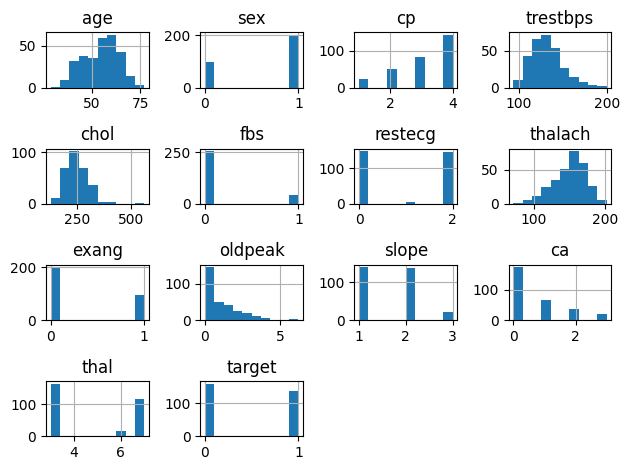

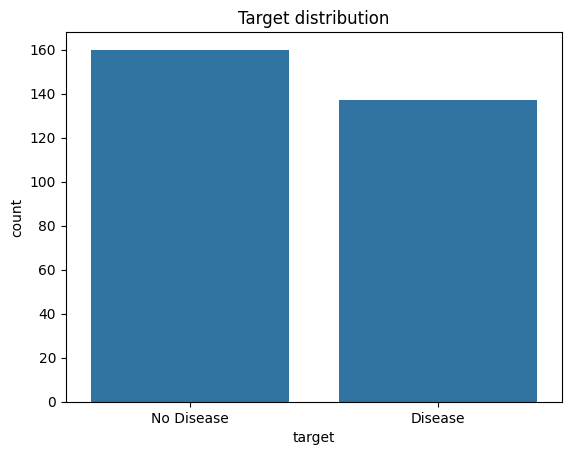

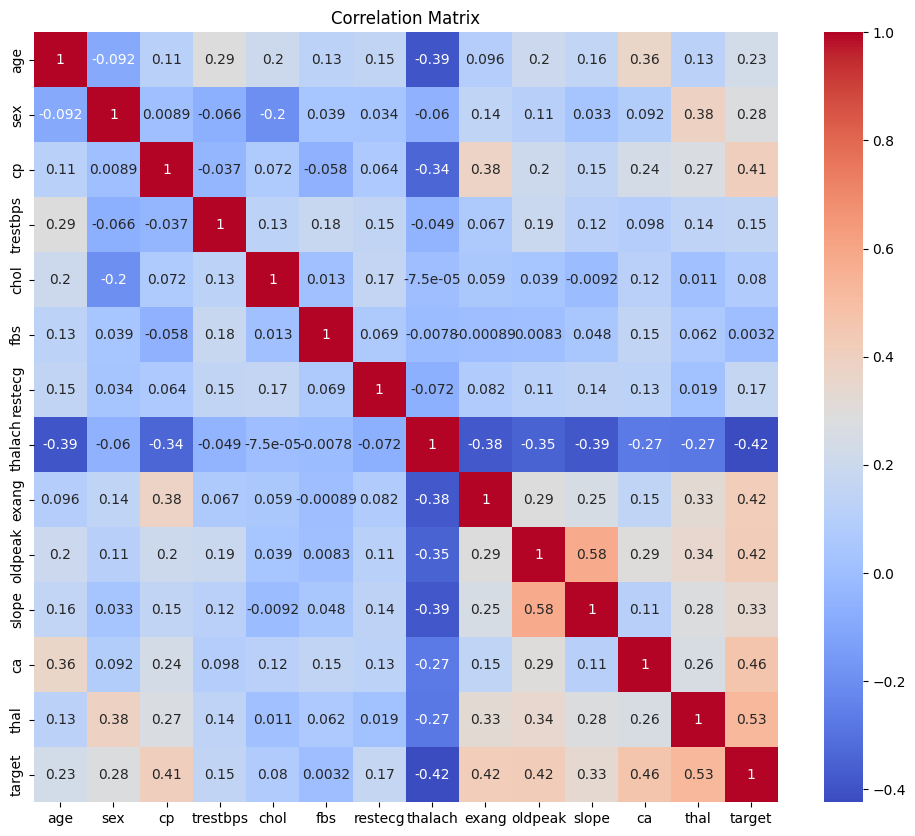

In [6]:
display(df.describe())

display(df['target'].value_counts())

df.hist()
plt.tight_layout()
plt.show()

sns.countplot(x='target', data=df)
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Target distribution')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Preprocessing

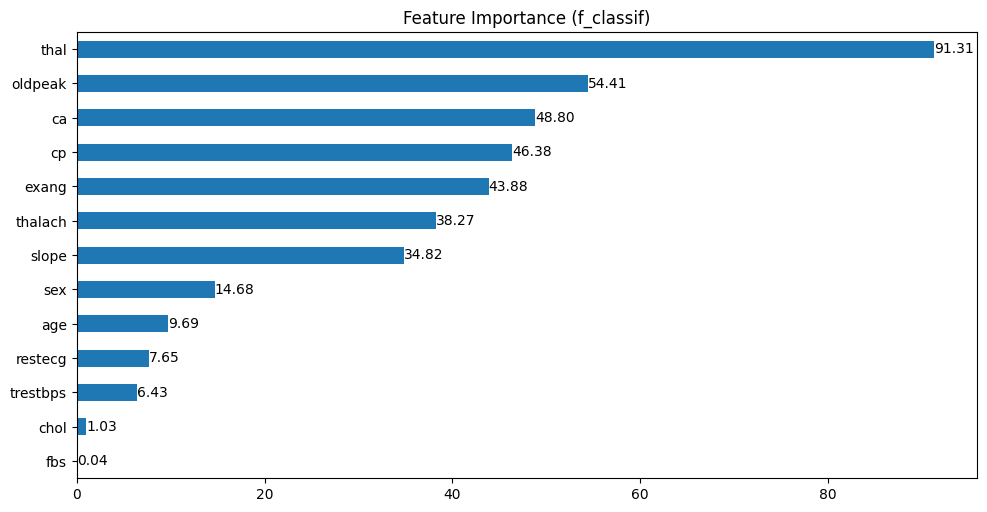

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=X.columns)
ax = scores.sort_values().plot(kind='barh', figsize=(10,5))
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.tight_layout()
plt.title('Feature Importance (f_classif)')
plt.show()
# Max correlation = 0.58, no need for changes

In [8]:
def model_summary(y_test, y_pred, title):
  cm = confusion_matrix(y_test, y_pred)
  acc = accuracy_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)

  print(f"Accuracy:  {acc:.4f}")
  print(f"Recall:    {rec:.4f}")
  print(f"Precision: {prec:.4f}")

  print('\n',classification_report(y_test, y_pred))
  sns.heatmap(cm, annot=True)
  plt.title(f'Confusion Matrix - {title}')
  plt.show()
  return acc, rec, prec

## 4. Działanie wykorzystanych algorytmów

### MLPClassifier (sieć neuronowa, scikit-learn)
Wielowarstwowy perceptron - sieć neuronów, z których każdy liczy ważoną sumę wejść i przepuszcza ją przez **funkcję aktywacji**. Uczy się propagacją wsteczną, korygując wagi tak, by minimalizować błąd. Wymaga przeskalowanych danych.

### Sieć w TensorFlow/Keras (GPU)
Dodatkowa sieć uruchomiona na GPU: warstwy gęste (`Dense`) z aktywacją ReLU, przeplatane warstwami `Dropout` (ogranicza przeuczenie). Wyjście z sigmoidą zwraca prawdopodobieństwo choroby; trening zatrzymuje `EarlyStopping` zapobiegający przeuczeniu.

### Support Vector Classifier (SVC)
Szuka **hiperpłaszczyzny** rozdzielającej klasy z maksymalnym marginesem. **Wrażliwy na skalowanie**.

### K-Nearest Neighbors (KNN)
Klasyfikuje na podstawie **k najbliższych** sąsiadów (metryka euklidesowa lub Manhattan), przypisując klasę większościową. Nie buduje modelu - liczy wszystko przy predykcji. **Zależny od skalowania i doboru `k`**.

### Random Forest Classifier (RFC)
Zespół wielu **drzew decyzyjnych**, każde trenowane na losowej próbce danych i cech. Las głosuje nad predykcjami drzew, co ogranicza przeuczenie. **Nie wymaga skalowania** i daje naturalną analizę ważności cech.

# Original dataset

## MLP

### Scikit-learn

Accuracy:  0.8667
Recall:    0.8571
Precision: 0.8571

               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88        32
         1.0       0.86      0.86      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



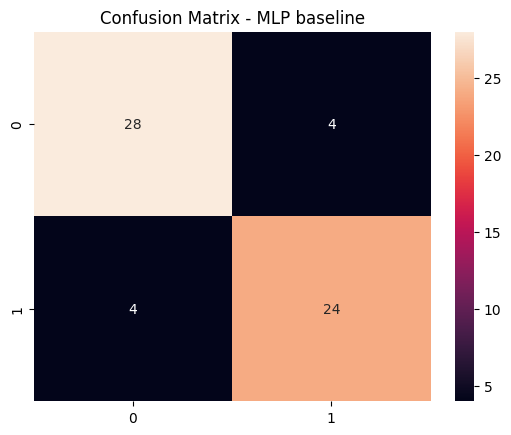

In [9]:
mlp_baseline = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_baseline.fit(X_train, y_train)

y_pred_MLP_baseline = mlp_baseline.predict(X_test)
results_a['MLP baseline'], results_r['MLP baseline'], results_p['MLP baseline'] = model_summary(y_test, y_pred_MLP_baseline, "MLP baseline")

Najlepsze parametry: {'activation': 'logistic', 'alpha': 1e-05, 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}
Recall (walidacja): 0.7965
Recall (test): 0.8214
Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



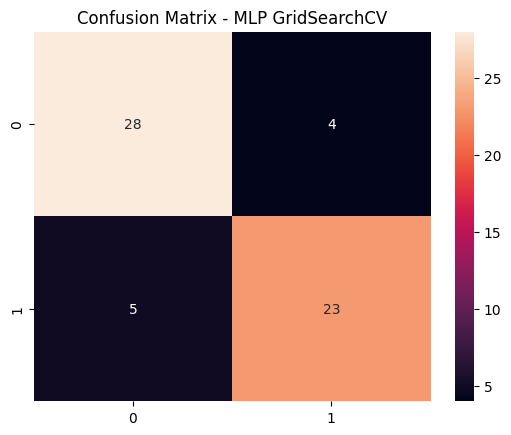

In [10]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (200,), (50, 50), (100, 50), (100, 100)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.00001, 0.0001, 0.001],
}

mlp_grid = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_grid = GridSearchCV(mlp_grid, param_grid_mlp, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
mlp_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {mlp_grid.best_params_}')
print(f'Recall (walidacja): {mlp_grid.best_score_:.4f}')
print(f'Recall (test): {mlp_grid.score(X_test, y_test):.4f}')

y_pred_MLP = mlp_grid.predict(X_test)
results_a['MLP GridSearchCV'], results_r['MLP GridSearchCV'], results_p['MLP GridSearchCV'] = model_summary(y_test, y_pred_MLP, "MLP GridSearchCV")

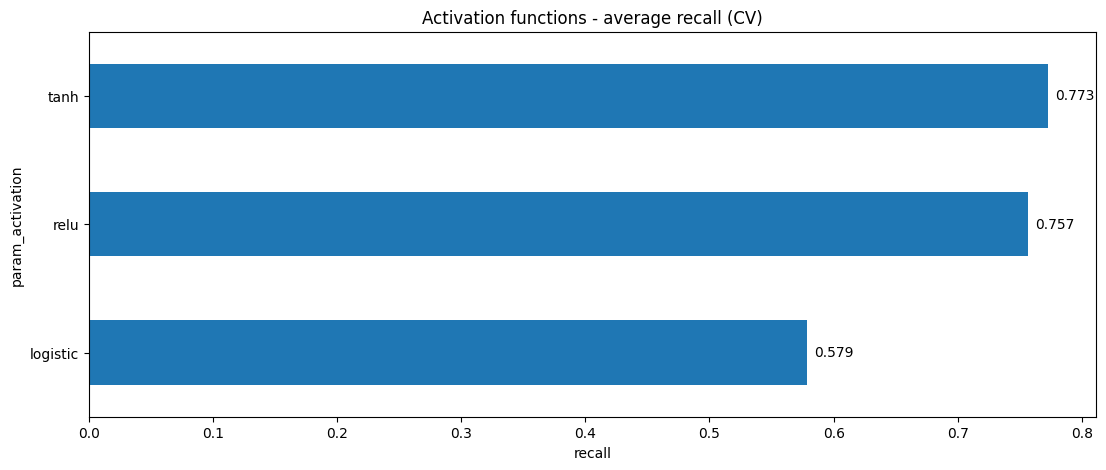

In [11]:
cv_results = pd.DataFrame(mlp_grid.cv_results_)
activation_results = cv_results.groupby('param_activation')['mean_test_score'].mean()
ax = activation_results.sort_values().plot(kind='barh', title=f'Activation functions - average {SCORING} (CV)', figsize=(13,5))
ax.bar_label(ax.containers[0], fmt='%.3f', padding=5)
plt.xlabel(SCORING)
plt.show()

### Tensorflow

In [12]:
tf.config.experimental.enable_op_determinism()
def train_model(hidden_layers:List[int], X_train, activation, optimizer, dropout, epochs):
  model = keras.Sequential()
  model.add(keras.layers.Input(shape=(X_train.shape[1],)))
  for i in hidden_layers:
    model.add(keras.layers.Dense(i, activation=activation))
    model.add(keras.layers.Dropout(dropout))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[SCORING])
  early_stop = keras.callbacks.EarlyStopping(monitor='val_recall', mode='max', patience=20, restore_best_weights=True)
  model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0, callbacks=[early_stop])
  return model

Dostępne GPU: []
[50] 0.8571
[100] 0.8929
[200] 0.7500
[50, 50] 0.7500
[100, 50] 0.8214
[100, 100] 0.8571
[200, 100] 0.7857
[100, 50, 25] 0.7857
[25, 50, 100] 0.8929
[100, 50, 100] 0.8214
Best: {'layers': [100], 'rec': 0.8928571343421936} 

Accuracy:  0.8667
Recall:    0.8929
Precision: 0.8333

               precision    recall  f1-score   support

         0.0       0.90      0.84      0.87        32
         1.0       0.83      0.89      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



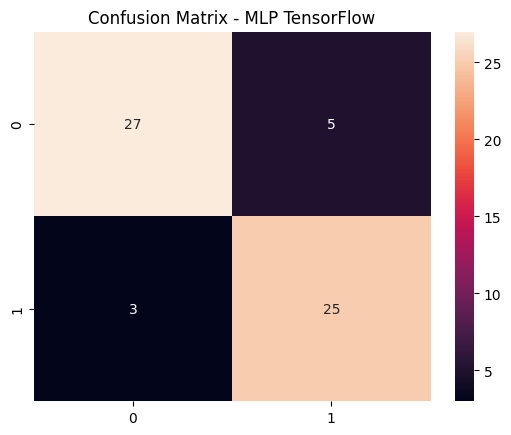

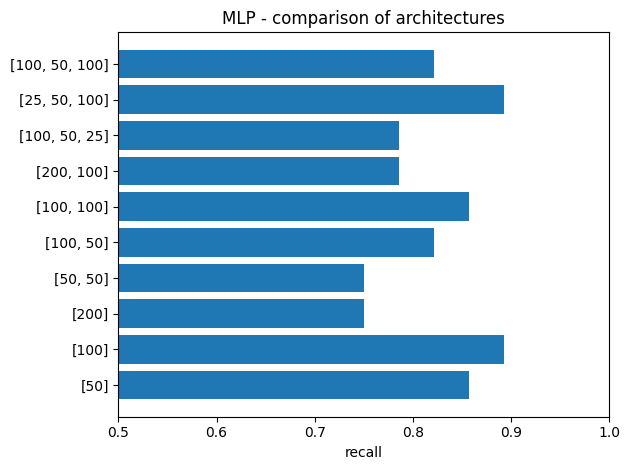

In [13]:
tf.keras.utils.set_random_seed(RANDOM_STATE)
print("Dostępne GPU:", tf.config.list_physical_devices('GPU'))
architectures = [
    [50],
    [100],
    [200],
    [50,50],
    [100,50],
    [100,100],
    [200,100],
    [100,50,25],
    [25,50,100],
    [100,50,100]
]
arch_res = []
best = {'rec': 0}

for layers in architectures:
  m = train_model(layers, X_train, 'relu', 'adam', 0.2, 200)
  rec = m.evaluate(X_test, y_test, verbose=0, return_dict=True)[SCORING]
  arch_res.append(rec)
  if best['rec'] < rec:
    best = {'layers': layers, 'rec': rec}
  print(f'{layers} {rec:.4f}')
print('Best:', best, '\n')

mlp_tensorflow = train_model(best['layers'], X_train, 'relu', 'adam', 0.2, 200)
y_pred_TF_proba = mlp_tensorflow.predict(X_test, verbose=0)
y_pred_TF = (y_pred_TF_proba > 0.4).astype(int)
results_a['MLP TensorFlow'], results_r['MLP TensorFlow'], results_p['MLP TensorFlow'] = model_summary(y_test, y_pred_TF, "MLP TensorFlow")

arch_labels = [str(a) for a in architectures]
plt.barh(arch_labels, arch_res)
plt.xlabel(SCORING)
plt.title('MLP - comparison of architectures')
plt.xlim(0.5, 1)
plt.tight_layout()
plt.show()

## SVC

### Baseline

Accuracy:  0.8500
Recall:    0.7857
Precision: 0.8800

               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        32
         1.0       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



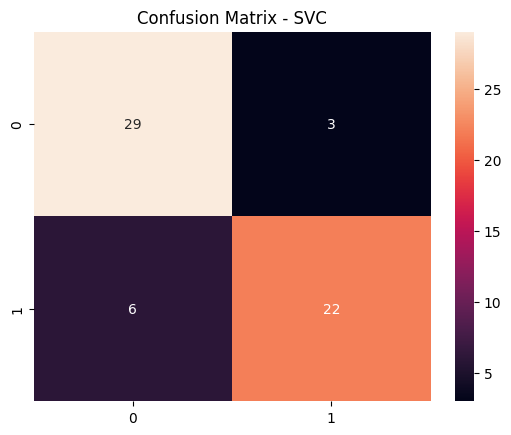

In [14]:
svc_baseline = SVC(random_state=RANDOM_STATE)
svc_baseline.fit(X_train, y_train)

y_pred_SVC_baseline = svc_baseline.predict(X_test)
results_a['SVC baseline'], results_r['SVC baseline'], results_p['SVC baseline'] = model_summary(y_test, y_pred_SVC_baseline, "SVC")

### GridSearchCV

Najlepsze parametry: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
Recall (walidacja): 0.8152
Recall (test): 0.7857
Accuracy:  0.8167
Recall:    0.7857
Precision: 0.8148

               precision    recall  f1-score   support

         0.0       0.82      0.84      0.83        32
         1.0       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



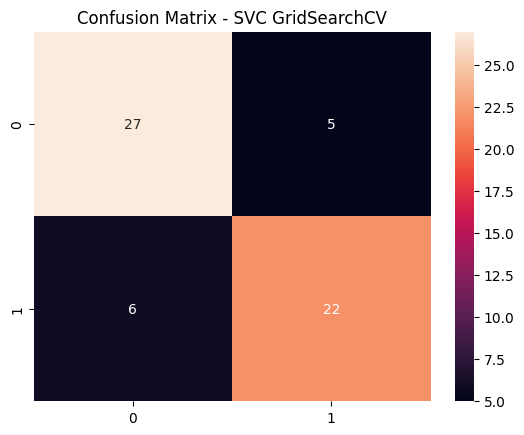

In [15]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

svc_grid = SVC(random_state=RANDOM_STATE)
svc_grid = GridSearchCV(svc_grid, param_grid_svc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
svc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {svc_grid.best_params_}')
print(f'Recall (walidacja): {svc_grid.best_score_:.4f}')
print(f'Recall (test): {svc_grid.score(X_test, y_test):.4f}')

y_pred_SVC = svc_grid.predict(X_test)
results_a['SVC GridSearchCV'], results_r['SVC GridSearchCV'], results_p['SVC GridSearchCV'] = model_summary(y_test, y_pred_SVC, "SVC GridSearchCV")

### Kernel comparison

In [16]:
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svc = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svc.fit(X_train, y_train)
    y_pred_k = svc.predict(X_test)
    print(f'{kernel:10s} {recall_score(y_test, y_pred_k):.4f}')

linear     0.7857
rbf        0.7857
poly       0.7857
sigmoid    0.7857


## KNeighborsClassifier

### Baseline

Accuracy:  0.8833
Recall:    0.8214
Precision: 0.9200

               precision    recall  f1-score   support

         0.0       0.86      0.94      0.90        32
         1.0       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



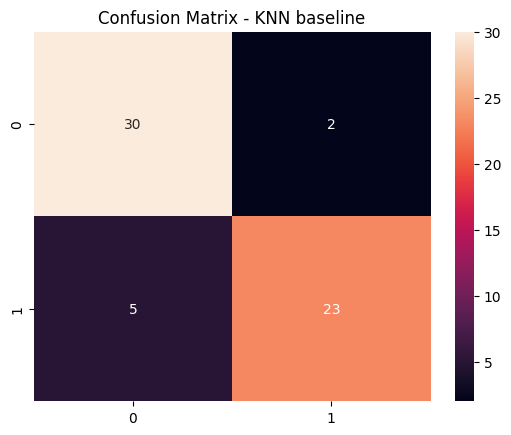

In [17]:
knn_base=KNC()
knn_base.fit(X_train,y_train)

y_pred_knn_base = knn_base.predict(X_test)
results_a['KNN baseline'], results_r['KNN baseline'], results_p['KNN baseline'] = model_summary(y_test, y_pred_knn_base, "KNN baseline")

### GridSearchCV

Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Recall (walidacja): 0.7874
Recall (test): 0.7857
Accuracy:  0.8667
Recall:    0.7857
Precision: 0.9167

               precision    recall  f1-score   support

         0.0       0.83      0.94      0.88        32
         1.0       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



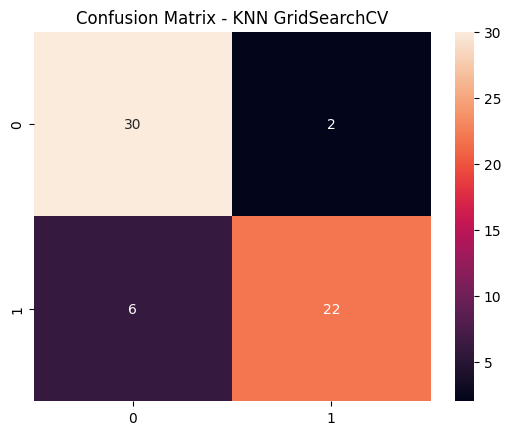

In [18]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = KNC()
knn_grid = GridSearchCV(knn_grid, param_grid_knn, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {knn_grid.best_params_}')
print(f'Recall (walidacja): {knn_grid.best_score_:.4f}')
print(f'Recall (test): {knn_grid.score(X_test, y_test):.4f}')

y_pred_knn = knn_grid.predict(X_test)
results_a['KNN GridSearchCV'], results_r['KNN GridSearchCV'], results_p['KNN GridSearchCV'] = model_summary(y_test, y_pred_knn, "KNN GridSearchCV")

## RandomForestClassifier

### Baseline

Accuracy:  0.8667
Recall:    0.8214
Precision: 0.8846

               precision    recall  f1-score   support

         0.0       0.85      0.91      0.88        32
         1.0       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



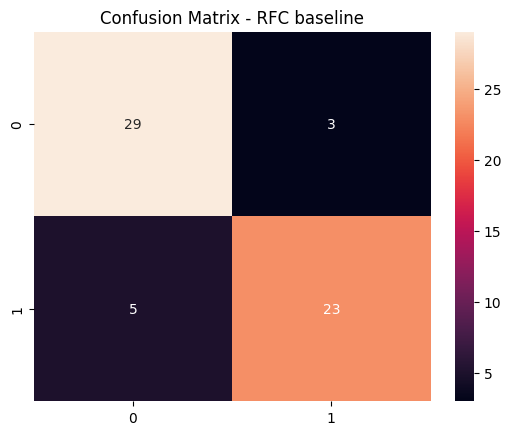

In [19]:
rfc_base = RFC(random_state=RANDOM_STATE)
rfc_base.fit(X_train, y_train)

y_pred_rfc_base = rfc_base.predict(X_test)
results_a['RFC baseline'], results_r['RFC baseline'], results_p['RFC baseline'] = model_summary(y_test, y_pred_rfc_base, "RFC baseline")

### GridSearchCV

Najlepsze parametry: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Recall (walidacja): 0.8061
Recall (test): 0.7500
Accuracy:  0.8333
Recall:    0.7500
Precision: 0.8750

               precision    recall  f1-score   support

         0.0       0.81      0.91      0.85        32
         1.0       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



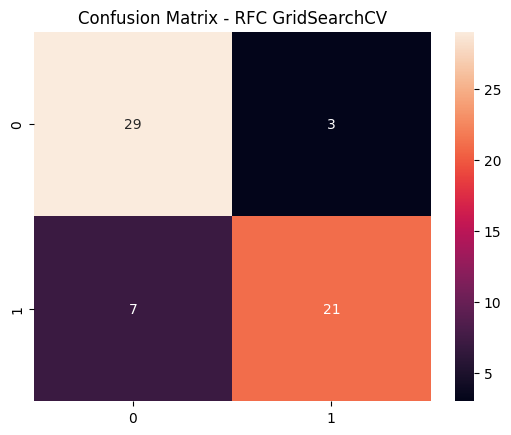

In [20]:
param_grid_rfc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_grid = RFC(random_state=RANDOM_STATE)
rfc_grid = GridSearchCV(rfc_grid, param_grid_rfc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
rfc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {rfc_grid.best_params_}')
print(f'Recall (walidacja): {rfc_grid.best_score_:.4f}')
print(f'Recall (test): {rfc_grid.score(X_test, y_test):.4f}')

y_pred_rfc = rfc_grid.predict(X_test)
results_a['RFC GridSearchCV'], results_r['RFC GridSearchCV'], results_p['RFC GridSearchCV'] = model_summary(y_test, y_pred_rfc, "RFC GridSearchCV")

### Feature importance

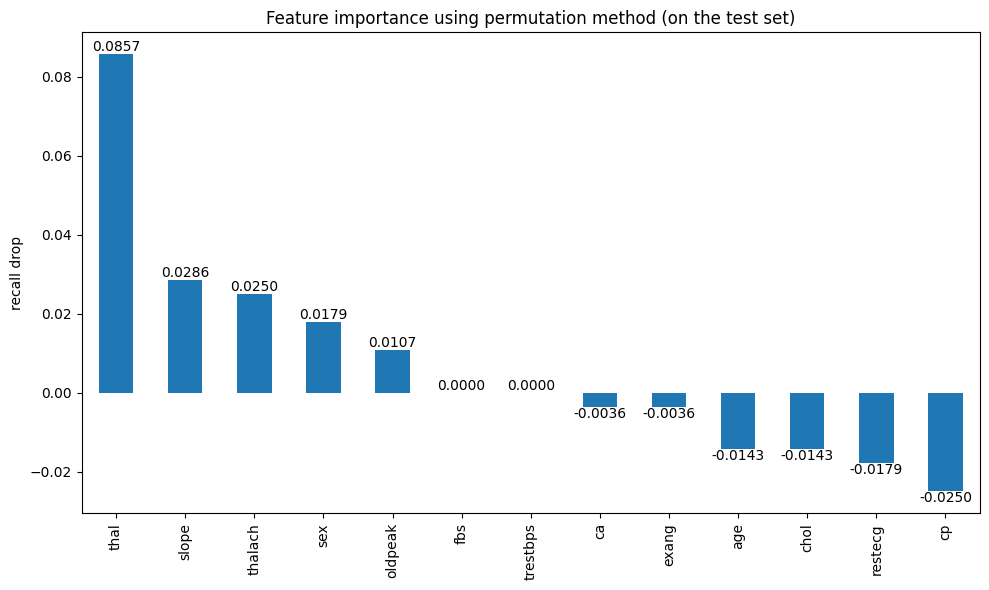

In [21]:
result = permutation_importance(
    rfc_grid, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring = SCORING
)

perm_importances = pd.Series(result.importances_mean, index=columns[0:13]).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = perm_importances.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='%.4f')
plt.title("Feature importance using permutation method (on the test set)")
plt.ylabel(f"{SCORING} drop")
plt.tight_layout()
plt.show()


## Base model comparison

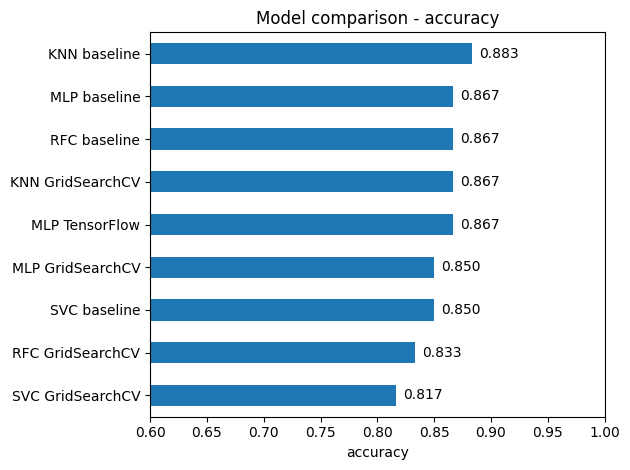

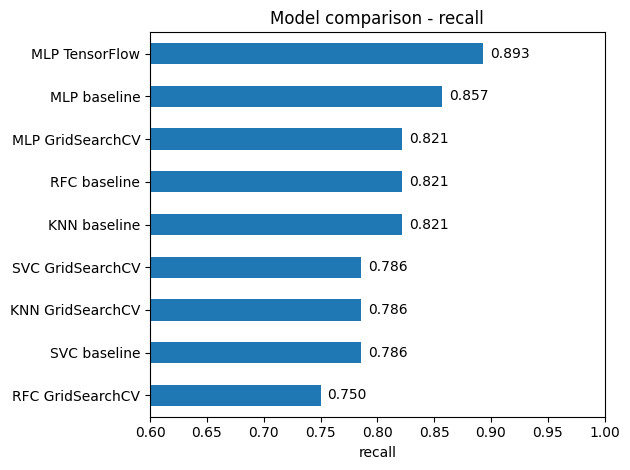

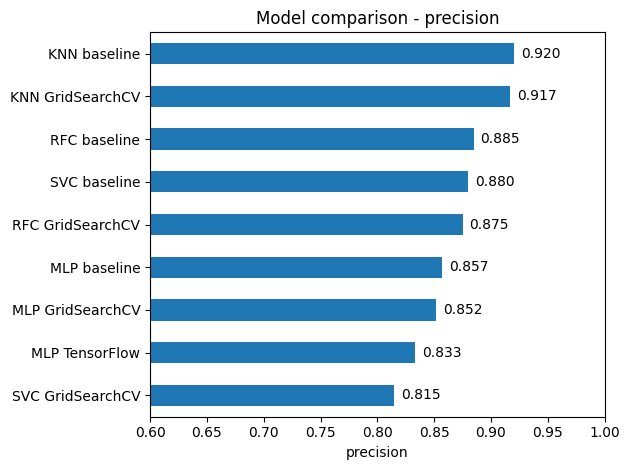

In [22]:
for name, r in {'accuracy': results_a, 'recall': results_r, 'precision': results_p}.items():
  ax = pd.Series(r).sort_values().plot(kind='barh', title=f'Model comparison - {name}')
  ax.bar_label(ax.containers[0], fmt='%.3f', padding=5)
  plt.xlabel(name)
  plt.xlim(0.6, 1.0)
  plt.tight_layout()
  plt.show()

# Reduced dataset

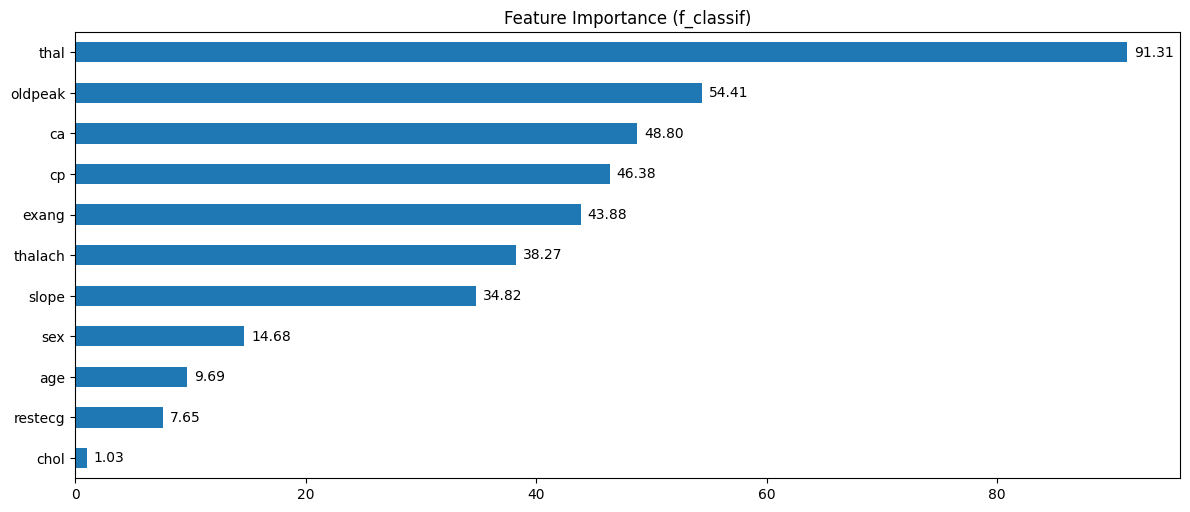

In [23]:
X_red = df.drop(['target', 'trestbps', 'fbs'], axis=1)
y = df['target']

X_train_red, X_test_red, y_train, y_test = train_test_split(X_red, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_red = scaler.fit_transform(X_train_red)
X_test_red = scaler.transform(X_test_red)

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train_red, y_train)

scores = pd.Series(selector.scores_, index=X_red.columns)
ax = scores.sort_values().plot(kind='barh', figsize=(12,5))
plt.tight_layout()
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5)
plt.title('Feature Importance (f_classif)')
plt.show()

## MLP

### Scikit-learn

Accuracy:  0.8333
Recall:    0.7857
Precision: 0.8462

               precision    recall  f1-score   support

         0.0       0.82      0.88      0.85        32
         1.0       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



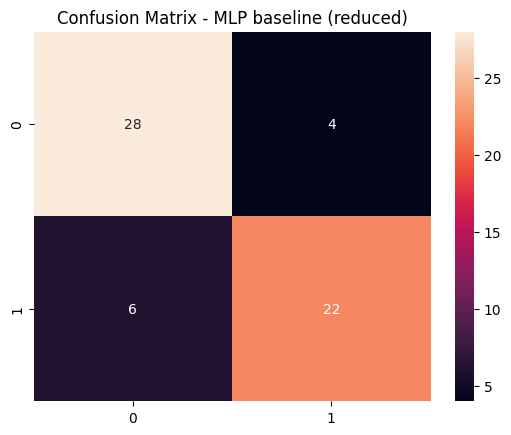

In [24]:
mlp_baseline_red = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_baseline_red.fit(X_train_red, y_train)

y_pred_MLP_baseline_red = mlp_baseline_red.predict(X_test_red)
results_a['MLP baseline (reduced)'], results_r['MLP baseline (reduced)'], results_p['MLP baseline (reduced)'] = model_summary(y_test, y_pred_MLP_baseline_red, "MLP baseline (reduced)")

Najlepsze parametry: {'activation': 'tanh', 'alpha': 1e-05, 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}
Recall (walidacja): 0.8333
Recall (test): 0.7143
Accuracy:  0.8500
Recall:    0.7143
Precision: 0.9524

               precision    recall  f1-score   support

         0.0       0.79      0.97      0.87        32
         1.0       0.95      0.71      0.82        28

    accuracy                           0.85        60
   macro avg       0.87      0.84      0.84        60
weighted avg       0.87      0.85      0.85        60



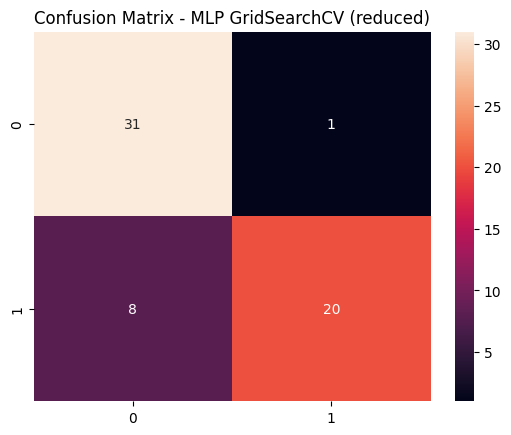

In [25]:
mlp_grid_red = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_grid_red = GridSearchCV(mlp_grid_red, param_grid_mlp, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
mlp_grid_red.fit(X_train_red, y_train)

print(f'Najlepsze parametry: {mlp_grid_red.best_params_}')
print(f'Recall (walidacja): {mlp_grid_red.best_score_:.4f}')
print(f'Recall (test): {mlp_grid_red.score(X_test_red, y_test):.4f}')

y_pred_MLP_red = mlp_grid_red.predict(X_test_red)
results_a['MLP GridSearchCV (reduced)'], results_r['MLP GridSearchCV (reduced)'], results_p['MLP GridSearchCV (reduced)'] = model_summary(y_test, y_pred_MLP_red, "MLP GridSearchCV (reduced)")

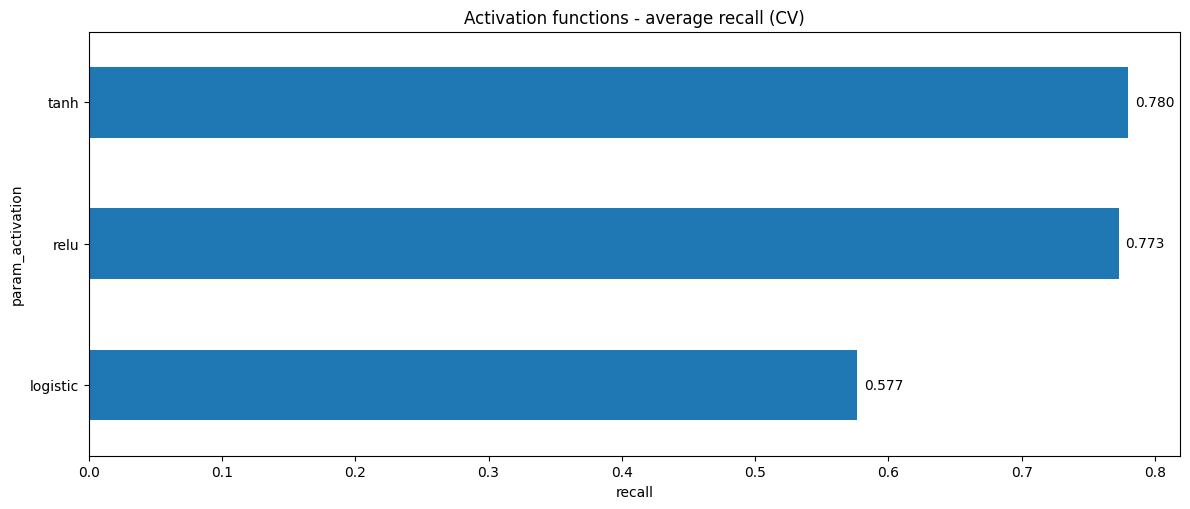

In [26]:
cv_results = pd.DataFrame(mlp_grid_red.cv_results_)
activation_results = cv_results.groupby('param_activation')['mean_test_score'].mean()
ax = activation_results.sort_values().plot(kind='barh', title=f'Activation functions - average {SCORING} (CV)', figsize=(12,5))
plt.tight_layout()
ax.bar_label(ax.containers[0], fmt='%.3f', padding=5)
plt.xlabel(SCORING)
plt.show()

### Tensorflow

Dostępne GPU: []
[50] 0.6071
[100] 0.9643
[200] 0.7857
[50, 50] 0.8571
[100, 50] 0.7143
[100, 100] 0.8214
[200, 100] 0.7857
[100, 50, 25] 0.7857
[25, 50, 100] 0.8929
[100, 50, 100] 0.7857
Best: {'layers': [100], 'rec': 0.9642857313156128} 

Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



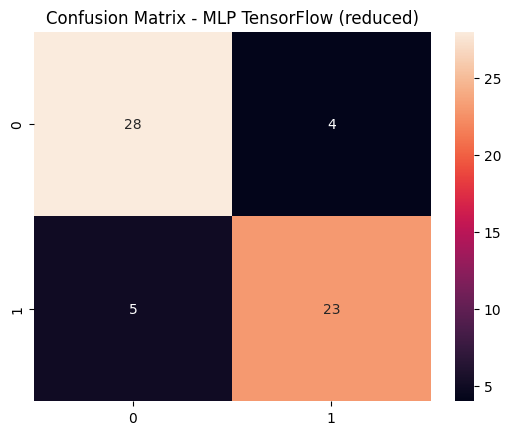

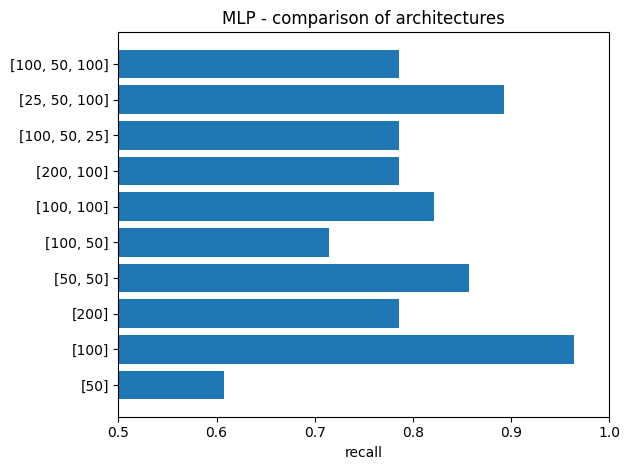

In [27]:
tf.keras.utils.set_random_seed(RANDOM_STATE)
print("Dostępne GPU:", tf.config.list_physical_devices('GPU'))
arch_res = []
best = {'rec': 0}

for layers in architectures:
  m = train_model(layers, X_train_red, 'relu', 'adam', 0.2, 200)
  rec = m.evaluate(X_test_red, y_test, verbose=0, return_dict=True)[SCORING]
  arch_res.append(rec)
  if best['rec'] < rec:
    best = {'layers': layers, 'rec': rec}
  print(f'{layers} {rec:.4f}')
print('Best:', best, '\n')

mlp_tensorflow_red = train_model(best['layers'], X_train_red, 'relu', 'adam', 0.2, 200)
y_pred_tensorflow_red_proba = mlp_tensorflow_red.predict(X_test_red, verbose=0)
y_pred_tensorflow_red = (y_pred_tensorflow_red_proba > 0.4).astype(int)
results_a['MLP TensorFlow (reduced)'], results_r['MLP TensorFlow (reduced)'], results_p['MLP TensorFlow (reduced)'] = model_summary(y_test, y_pred_tensorflow_red, "MLP TensorFlow (reduced)")

arch_labels = [str(a) for a in architectures]
plt.barh(arch_labels, arch_res)
plt.xlabel(SCORING)
plt.title('MLP - comparison of architectures')
plt.xlim(0.5, 1)
plt.tight_layout()
plt.show()

## SVC

### Baseline

Accuracy:  0.8500
Recall:    0.7143
Precision: 0.9524

               precision    recall  f1-score   support

         0.0       0.79      0.97      0.87        32
         1.0       0.95      0.71      0.82        28

    accuracy                           0.85        60
   macro avg       0.87      0.84      0.84        60
weighted avg       0.87      0.85      0.85        60



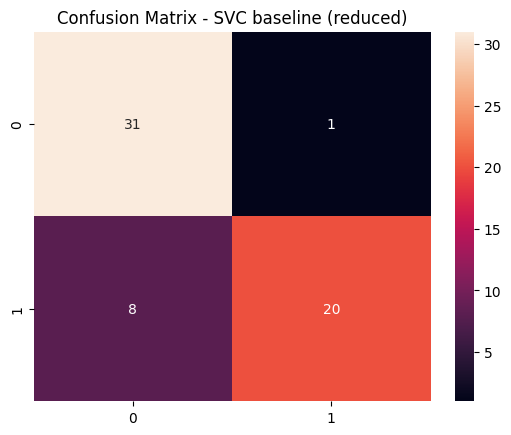

In [28]:
svc_baseline_red = SVC(random_state=RANDOM_STATE)
svc_baseline_red.fit(X_train_red, y_train)

y_pred_SVC_baseline_red = svc_baseline_red.predict(X_test_red)
results_a['SVC baseline (reduced)'], results_r['SVC baseline (reduced)'], results_p['SVC baseline (reduced)'] = model_summary(y_test, y_pred_SVC_baseline_red, "SVC baseline (reduced)")

### GridSearchCV

Najlepsze parametry: {'C': 100, 'gamma': 'scale', 'kernel': 'sigmoid'}
Recall (walidacja): 0.7883
Recall (test): 0.7143
Accuracy:  0.8000
Recall:    0.7143
Precision: 0.8333

               precision    recall  f1-score   support

         0.0       0.78      0.88      0.82        32
         1.0       0.83      0.71      0.77        28

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60



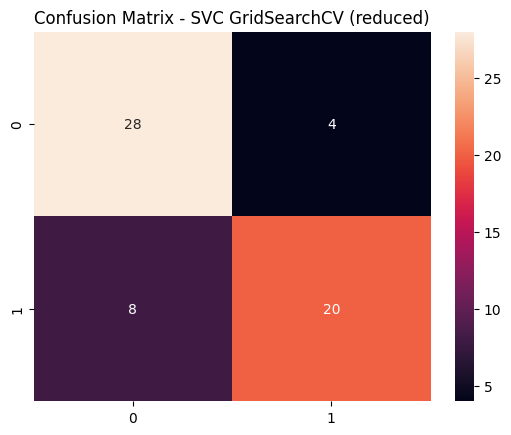

In [29]:
svc_grid_red = SVC(random_state=RANDOM_STATE)
svc_grid_red = GridSearchCV(svc_grid_red, param_grid_svc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
svc_grid_red.fit(X_train_red, y_train)

print(f'Najlepsze parametry: {svc_grid_red.best_params_}')
print(f'Recall (walidacja): {svc_grid_red.best_score_:.4f}')
print(f'Recall (test): {svc_grid_red.score(X_test_red, y_test):.4f}')

y_pred_SVC_red = svc_grid_red.predict(X_test_red)
results_a['SVC GridSearchCV (reduced)'], results_r['SVC GridSearchCV (reduced)'], results_p['SVC GridSearchCV (reduced)'] = model_summary(y_test, y_pred_SVC_red, "SVC GridSearchCV (reduced)")

### Kernel comparison

In [30]:
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svc = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svc.fit(X_train_red, y_train)
    print(f'{kernel:10s} {recall_score(y_test, svc.predict(X_test_red)):.4f}')

linear     0.7857
rbf        0.7143
poly       0.7143
sigmoid    0.7857


## KNeighborsClassifier

### Baseline

Accuracy:  0.8833
Recall:    0.8214
Precision: 0.9200

               precision    recall  f1-score   support

         0.0       0.86      0.94      0.90        32
         1.0       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



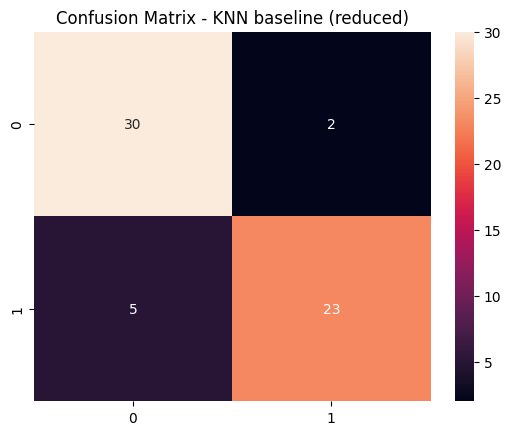

In [31]:
knn_base_red=KNC()
knn_base_red.fit(X_train_red,y_train)

y_pred_knn_base_red = knn_base_red.predict(X_test_red)
results_a['KNN baseline (reduced)'], results_r['KNN baseline (reduced)'], results_p['KNN baseline (reduced)'] = model_summary(y_test, y_pred_knn_base_red, "KNN baseline (reduced)")

### GridSearchCV

Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Recall (walidacja): 0.8429
Recall (test): 0.7143
Accuracy:  0.8333
Recall:    0.7143
Precision: 0.9091

               precision    recall  f1-score   support

         0.0       0.79      0.94      0.86        32
         1.0       0.91      0.71      0.80        28

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60



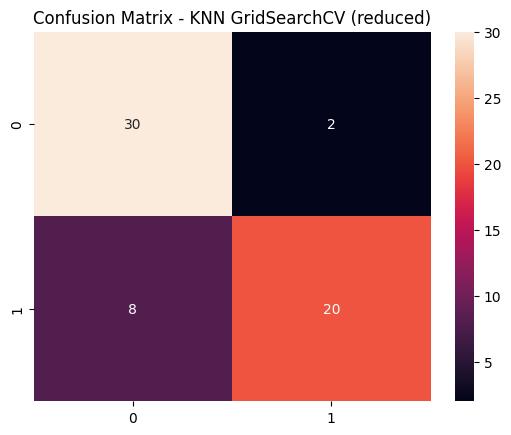

In [32]:
knn_grid_red = KNC()
knn_grid_red = GridSearchCV(knn_grid_red, param_grid_knn, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
knn_grid_red.fit(X_train_red, y_train)

print(f'Najlepsze parametry: {knn_grid_red.best_params_}')
print(f'Recall (walidacja): {knn_grid_red.best_score_:.4f}')
print(f'Recall (test): {knn_grid_red.score(X_test_red, y_test):.4f}')

y_pred_knn_red = knn_grid_red.predict(X_test_red)
results_a['KNN GridSearchCV (reduced)'], results_r['KNN GridSearchCV (reduced)'], results_p['KNN GridSearchCV (reduced)'] = model_summary(y_test, y_pred_knn_red, "KNN GridSearchCV (reduced)")

## RandomForestClassifier

### Baseline

Accuracy:  0.8333
Recall:    0.7500
Precision: 0.8750

               precision    recall  f1-score   support

         0.0       0.81      0.91      0.85        32
         1.0       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



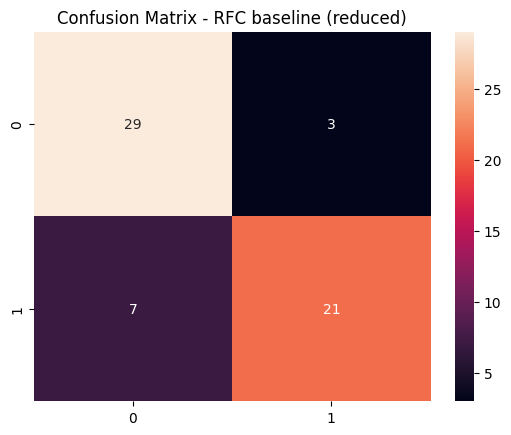

In [33]:
rfc_base_red = RFC(random_state=RANDOM_STATE)
rfc_base_red.fit(X_train_red, y_train)

y_pred_rfc_base_red = rfc_base_red.predict(X_test_red)
results_a['RFC baseline (reduced)'], results_r['RFC baseline (reduced)'], results_p['RFC baseline (reduced)'] = model_summary(y_test, y_pred_rfc_base_red, "RFC baseline (reduced)")

### GridSearchCV

Najlepsze parametry: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Recall (walidacja): 0.7970
Recall (test): 0.7143
Accuracy:  0.8167
Recall:    0.7143
Precision: 0.8696

               precision    recall  f1-score   support

         0.0       0.78      0.91      0.84        32
         1.0       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60



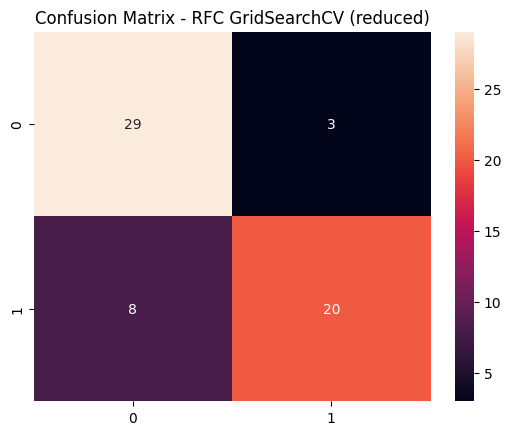

In [34]:
rfc_grid_red = RFC(random_state=RANDOM_STATE)
rfc_grid_red = GridSearchCV(rfc_grid_red, param_grid_rfc, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
rfc_grid_red.fit(X_train_red, y_train)

print(f'Najlepsze parametry: {rfc_grid_red.best_params_}')
print(f'Recall (walidacja): {rfc_grid_red.best_score_:.4f}')
print(f'Recall (test): {rfc_grid_red.score(X_test_red, y_test):.4f}')

y_pred_rfc_red = rfc_grid_red.predict(X_test_red)
results_a['RFC GridSearchCV (reduced)'], results_r['RFC GridSearchCV (reduced)'], results_p['RFC GridSearchCV (reduced)'] = model_summary(y_test, y_pred_rfc_red, "RFC GridSearchCV (reduced)")

### Feature importance

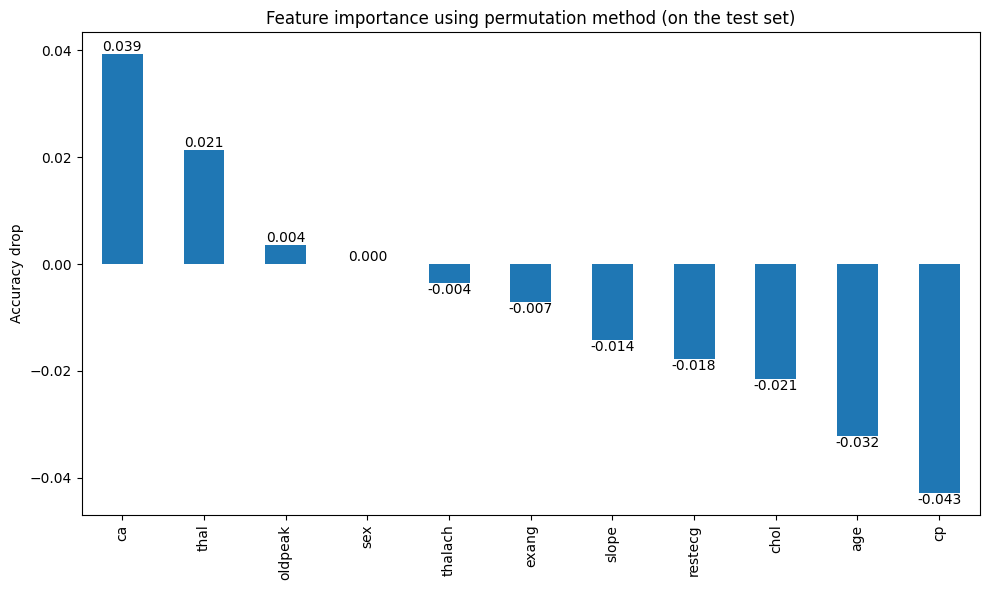

In [35]:
result = permutation_importance(
    rfc_grid_red, X_test_red, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring = SCORING
)

perm_importances = pd.Series(result.importances_mean, index=X_red.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = perm_importances.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='%.3f')
plt.title("Feature importance using permutation method (on the test set)")
plt.ylabel("Accuracy drop")
plt.tight_layout()
plt.show()

## 5. Optymalizacja i dobór parametrów

Parametry dobrano metodą **GridSearchCV** (5-krotna walidacja krzyżowa, optymalizacja pod **recall**). Sieć TensorFlow, nieintegrującą się natywnie z GridSearchCV, optymalizowano ręcznym przeszukiwaniem architektur.

### Najlepsze parametry (pełny zbiór)

| Model | Najlepsze parametry |
|-------|---------------------|
| MLP | aktywacja: logistic, alpha: 0.00001, warstwy: (50, 50), solver: adam |
| SVC | C: 10, gamma: scale, kernel: poly |
| KNN | metryka: manhattan, k: 7, wagi: uniform |
| RFC | drzewa: 200, max_depth: 10, max_features: sqrt, min_samples_leaf: 4 |
| Sieć TensorFlow | architektura: [100] (jedna warstwa ukryta, 100 neuronów) |

### Funkcje aktywacji (MLP)
Średni recall (CV): **tanh 0.773, ReLU 0.757, logistic 0.579**. Tanh jest najbardziej niezawodna, logistyczna najsłabsza. Co ciekawe, pojedynczy najlepszy zestaw w GridSearch wykorzystał logistic - pokazuje to, że najlepsza *pojedyncza* konfiguracja bywa przypadkowa, a uśrednienie (tanh) jest wiarygodniejsze.

### Jądra (SVC)
Na zbiorze testowym **wszystkie cztery jądra dały identyczny recall (0.786)** - wybór jądra nie wpłynął na wykrywalność chorych. GridSearch wskazał jądro wielomianowe, ale nie poprawiło to wyniku, więc dla tego problemu znikome znaczenie.

### Architektura sieci TensorFlow
Spośród testowanych architektur najlepsza okazała się najprostsza - **jedna warstwa ukryta ze 100 neuronami**. Większe sieci nie poprawiały wyników (nasycenie przy małym zbiorze treningowym).

## 6. Analiza ważności cech

Ważność cech zbadano dwiema metodami odpowiadającymi na różne pytania.

### f_classif (ANOVA) - związek cechy z diagnozą
Mierzy, jak silnie cecha **sama w sobie** różnicuje chorych i zdrowych: **thal (91.3)**, oldpeak (54.4), ca (48.8), cp (46.4), exang (43.9), thalach (38.3), slope (34.8), sex (14.7), age (9.7), restecg (7.7), trestbps (6.4), chol (1.0), fbs (0.04).

### Permutation importance (RFC) - wykorzystanie cechy przez model
Mierzy spadek skuteczności po przetasowaniu cechy, czyli na ile **model z niej korzysta**. Dominuje również **thal (0.086)**, dalej slope, thalach, sex. Wiele cech ma wartości bliskie zera lub lekko ujemne (szum przy 60 próbkach).

### Interpretacja rozbieżności
Obie metody zgodnie wskazują **thal jako najsilniejszy predyktor**. Różnią się w środku rankingu - np. `cp` jest 4. w f_classif, lecz bliskie zera w permutacji. Powód: f_classif ocenia cechę w izolacji, permutacja - w kontekście modelu. Cecha może być przewidująca samodzielnie, lecz **redundantna**, gdy model ma dostęp do cech skorelowanych.

### Wpływ usunięcia cech
Najsłabsze w obu metodach to `fbs` i `trestbps` - przetestowano zbiór bez nich. Jak pokazuje rozdział 7, **redukcja nie poprawiła wyników**. Modele zredukowane są w granicach błędu identyczne z pełnymi. Nawet słabe cechy wnoszą marginalną informację, a ich usunięcie ani nie szkodzi, ani nie pomaga znacząco.

# Overall model comparison

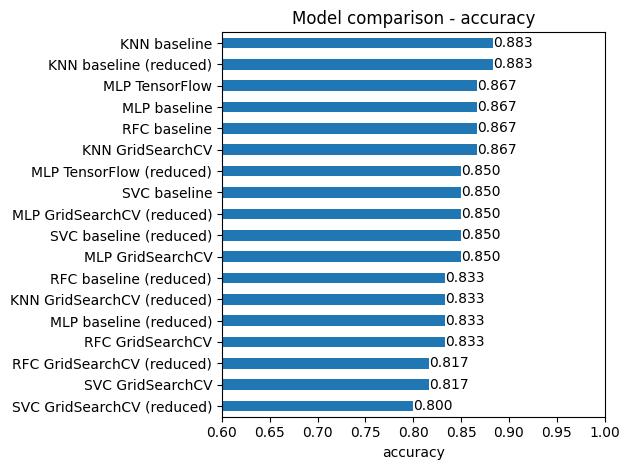

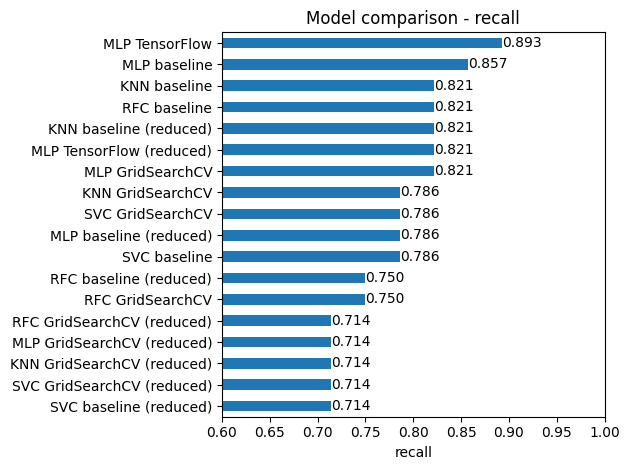

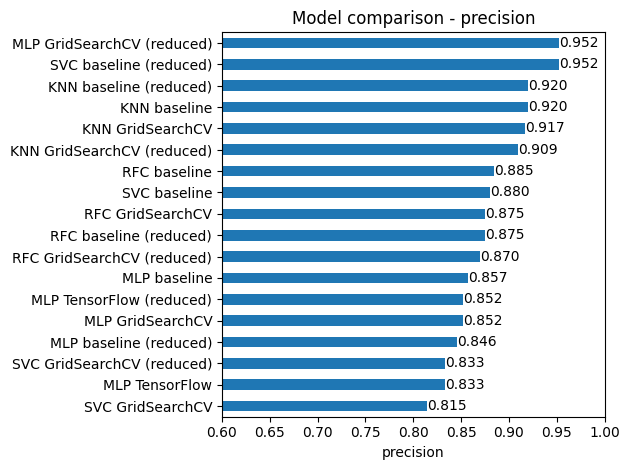

In [36]:
for name, r in {'accuracy': results_a, 'recall': results_r, 'precision': results_p}.items():
  ax = pd.Series(r).sort_values().plot(kind='barh', title=f'Model comparison - {name}')
  ax.bar_label(ax.containers[0], fmt='%.3f')
  plt.xlabel(name)
  plt.xlim(0.6, 1.0)
  plt.tight_layout()
  plt.show()

# Cross validation

## 7. Wyniki i zmienność algorytmów

### Problem małego zbioru testowego
Zbiór testowy liczy tylko **60 próbek (28 chorych)**. Recall zmienia się skokowo co **~3.6%** - jeden błędnie sklasyfikowany pacjent zmienia wyniki diametralnie. Pojedynczy wynik testowy jest więc **wysoce niestabilny**.

### Walidacja krzyżowa - stabilna ocena
Zastosowano `RepeatedStratifiedKFold` (5 podziałów × 10 powtórzeń = 50 ewaluacji na model), podając średnią ± odchylenie. Wszystkie modele uzyskały recall w wąskim przedziale **0.74-0.80**.

**Sieć TensorFlow nie została ujęta** w tym porównaniu, ponieważ model Keras nie jest kompatybilny z `cross_val_score` ze scikit-learn. Oceniono ją na zbiorze testowym (recall 0.89), co mieści się w przedziale pozostałych modeli.

Różnice między modelami (<0.06 w recall) są niewielkie. **Recall zmienia się bardziej przez sam podział danych niż przez wybór modelu**. Na 60-elementowym zbiorze testowym odpowiada to różnicy zaledwie **1–3 pacjentów**. Nie pozwala to wskazać jednego modelu jako wiarygodnie najlepszego - wymaga to testu na większym zbiorze.

### Wpływ optymalizacji i redukcji cech
- **GridSearch nie poprawił wyników istotnie.** Różnice baseline vs tuned (−0.05 do +0.02) są kilkukrotnie **mniejsze niż odchylenie.**
- **Redukcja cech nie zmieniła wyników** - każda para pełny/zredukowany różni się o ~0.01, głęboko w granicach szumu.

### Test vs walidacja krzyżowa
Najlepszy na pojedynczym teście (sklearn MLP, recall do 0.86) wypada przeciętnie w CV (~0.78). Rankingi z testu i z CV się nie pokrywają, co dowodzi, że pojedynczy podział jest niewiarygodny - **rzeczywista najlepsza skuteczność to ok. 0.80 +/- 0.09** dla MLP po dostrajaniu.

In [37]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

models = {
    'MLP base':        (make_pipeline(StandardScaler(), MLPClassifier(max_iter=2000, random_state=RANDOM_STATE)), X),
    'MLP tuned':       (make_pipeline(StandardScaler(), MLPClassifier(**mlp_grid.best_params_, max_iter=2000, random_state=RANDOM_STATE)), X),
    'SVC base':        (make_pipeline(StandardScaler(), SVC(random_state=RANDOM_STATE)), X),
    'SVC tuned':       (make_pipeline(StandardScaler(), SVC(**svc_grid.best_params_, random_state=RANDOM_STATE)), X),
    'KNN base':        (make_pipeline(StandardScaler(), KNC()), X),
    'KNN tuned':       (make_pipeline(StandardScaler(), KNC(**knn_grid.best_params_)), X),
    'RFC base':        (make_pipeline(StandardScaler(), RFC(random_state=RANDOM_STATE)), X),
    'RFC tuned':       (make_pipeline(StandardScaler(), RFC(**rfc_grid.best_params_, random_state=RANDOM_STATE)), X),
    'MLP base (red)':  (make_pipeline(StandardScaler(), MLPClassifier(max_iter=2000, random_state=RANDOM_STATE)), X_red),
    'MLP tuned (red)': (make_pipeline(StandardScaler(), MLPClassifier(**mlp_grid_red.best_params_, max_iter=2000, random_state=RANDOM_STATE)), X_red),
    'SVC base (red)':  (make_pipeline(StandardScaler(), SVC(random_state=RANDOM_STATE)), X_red),
    'SVC tuned (red)': (make_pipeline(StandardScaler(), SVC(**svc_grid_red.best_params_, random_state=RANDOM_STATE)), X_red),
    'KNN base (red)':  (make_pipeline(StandardScaler(), KNC()), X_red),
    'KNN tuned (red)': (make_pipeline(StandardScaler(), KNC(**knn_grid_red.best_params_)), X_red),
    'RFC base (red)':  (make_pipeline(StandardScaler(), RFC(random_state=RANDOM_STATE)), X_red),
    'RFC tuned (red)': (make_pipeline(StandardScaler(), RFC(**rfc_grid_red.best_params_, random_state=RANDOM_STATE)), X_red),
}

rows = []
for name, (model, Xset) in models.items():
    scores = cross_val_score(model, Xset, y, cv=cv, scoring=SCORING)
    rows.append({'model': name, SCORING: scores.mean(), 'std': scores.std()})

cv_df = pd.DataFrame(rows).set_index('model').sort_values('recall', ascending=False)
display(cv_df.round(3))

,recall,std
model,,
MLP tuned,0.796,0.092
KNN base (red),0.785,0.092
KNN tuned (red),0.785,0.088
SVC base,0.781,0.092
KNN base,0.779,0.093
MLP base,0.776,0.079
MLP tuned (red),0.775,0.094
MLP base (red),0.775,0.094
SVC base (red),0.775,0.096


## 8. Analiza błędów - których pacjentów model myli

Analizę wykonano na najlepszym pod względem recall modelu (sieć TensorFlow). Na 60 pacjentów zbioru testowego model popełnił 8 błędów: **3 fałszywie negatywne (FN)** - chorzy uznani za zdrowych, oraz **5 fałszywie pozytywnych (FP)** - zdrowi uznani za chorych. W kontekście medycznym kluczowe są te 3 przeoczenia chorych (FN), bo to najkosztowniejszy typ błędu.

Poniższa tabela porównuje **uśredniony, standaryzowany profil** pacjentów przeoczonych (FN) z poprawnie wykrytymi chorymi (TP). Wartości to odchylenia od średniej (0 = przeciętny pacjent). Najistotniejsze są cechy o **największej różnicy między FN a TP** -  one tłumaczą, dlaczego model myli grupę.

### Wzorzec błędów

Poprawnie wykryci chorzy (TP) wykazują objawy typowe dla choroby w tym zbiorze:
- `thalach -` = niskie tętno maksymalne
- `slope +`, `cp +` = nieprawidłowe nachylenie ST oraz typ bólu skojarzony z chorobą
- `exang +` = obecność dławicy wysiłkowej
- `oldpeak +` = większe obniżenie odcinka ST
- `ca +` = więcej zajętych naczyń krwionośnych

Przeoczeni chorzy (FN) mają profil **odwrotny - wyglądający „zdrowo"**: wyższe tętno maksymalne (thalach = +0.10), brak dławicy wysiłkowej (exang = −0.73), niskie oldpeak (−0.56) oraz niski cp (−0.89). Są to pacjenci, u których choroba **nie ukazuje się w cechach najsilniej z nią skorelowanych.**

### Wniosek

Model najlepiej radzi sobie z typowymi przypadkami o wyraźnych objawach, a myli się na **przypadkach nietypowych** - chorych bez klasycznych symptomów. Ze względu na małą liczbę błędów (3 FN) wniosek ma charakter poglądowy, ale kierunek jest spójny i klinicznie uzasadniony: trudność stanowią pacjenci „bezobjawowi", u których diagnoza wymagałaby cech spoza dostępnego zbioru.

In [38]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_test_df['true'], X_test_df['pred'] = y_test.values, y_pred_TF  # best recall

fn = X_test_df[(X_test_df.true == 1) & (X_test_df.pred == 0)]
fp = X_test_df[(X_test_df.true == 0) & (X_test_df.pred == 1)]
tp = X_test_df[(X_test_df.true == 1) & (X_test_df.pred == 1)]

print(f'FN: {len(fn)}\nFP: {len(fp)}')

data = pd.concat([
    fn[columns[0:-1]].mean().rename('FN'),
    tp[columns[0:-1]].mean().rename('TP')
], axis=1).round(2)
data['difference'] = data['TP'] - data['FN']
display(data.sort_values('difference', ascending=False))

FN: 3
FP: 5


,FN,TP,difference
cp,-0.89,0.48,1.37
exang,-0.73,0.45,1.18
oldpeak,-0.56,0.47,1.03
slope,-0.41,0.48,0.89
ca,-0.01,0.83,0.84
age,-0.38,0.31,0.69
thal,-0.24,0.43,0.67
restecg,-0.32,0.26,0.58
trestbps,-0.39,0.00,0.39
fbs,-0.45,-0.34,0.11


## 9. Wnioski

**Skuteczność.** Wszystkie cztery algorytmy osiągnęły zbliżone wyniki: recall ok. **0.78 +/- 0.09** (walidacja krzyżowa), accuracy najlepszych modeli rzędu **88-85%** na zbiorze testowym.

**Najlepsze rozwiązanie.** Wobec nierozróżnialności statystycznej wybór modelu zależy od kryterium drugorzędnego: najwyższy recall w CV uzyskał **MLP/KNN**, najwyższą precyzję na teście - KNN. Dla kontekstu medycznego sensowny jest model o najwyższym recall przy akceptowalnej precyzji.

**Wybór metryki.** Optymalizowano pod **recall**, bo przeoczenie chorego (false negative) jest groźniejsze niż fałszywy alarm. Accuracy raportowano pomocniczo.

**Ważność cech.** Najsilniejszy predyktor to **thal** (talasemia), potwierdzony obiema metodami. `fbs` i `trestbps` są najsłabsze, a ich usunięcie nie wpływa znacząco na wyniki.

**Główny wniosek.** Ani GridSearch, ani redukcja cech nie dały istotnej poprawy - to skutek **małego zbioru (297 rekordów)**, przy którym wyniki są zaszumione. Na danych tej wielkości dostrajanie nie zastąpi większej liczby obserwacji.